<a href="https://colab.research.google.com/github/vishnubyneni/MLA0202-MACHINE-LEARNING/blob/main/k_Means_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

* This dataset captures Instagram users' visit scores and their spending rank (on a scale of 0 to 100).
* The goal is to analyze and group users into distinct clusters based on their behaviors, enabling insights into user engagement and spending potential.
* The dataset is suitable for unsupervised machine learning techniques like K-Means clustering, which can help identify patterns and group users effectively.

* Dataset Highlights:
* Ideal for practicing clustering algorithms.
* Small and easy-to-handle dataset.
* Includes key metrics for user behavior analysis.

# STEP -1(Businesss Understanding)
* Here the goal is to analyze the grouo of users on their behaviour,user enganement and spending poteintial
* form clusters high,low,medium.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Understanding

In [ ]:
df=pd.read_excel("/content/archive.xlsx")

In [ ]:
df

,User ID,Instagram visit score,Spending_rank(0 to 100)
0,0,63,24.050708
1,1,61,25.223290
2,2,104,18.528245
3,3,82,86.890232
4,4,14,31.492397
...,...,...,...
2549,2595,25,25.745908
2550,2596,52,9.275066
2551,2597,100,84.999487
2552,2598,87,20.530806


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2554 entries, 0 to 2553
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   User ID                  2554 non-null   int64  
 1   Instagram visit score    2554 non-null   int64  
 2   Spending_rank(0 to 100)  2554 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 60.0 KB


* There are three columns
* total rows are "2554"
* one column is float and another two is int data type
* here the data is continous

In [ ]:
df.describe()

,User ID,Instagram visit score,Spending_rank(0 to 100)
count,2554.000000,2554.000000,2554.000000
mean,1299.157792,63.233751,42.793807
std,751.068995,26.616508,28.712436
min,0.000000,5.000000,0.940709
25%,648.250000,38.000000,19.404789
50%,1298.500000,72.000000,28.006211
75%,1948.750000,86.000000,72.017869
max,2599.000000,118.000000,106.939372


* we observe that total 2554 rows
* obesrved average of each column
* got here standard deviation
* in both insagram visit scire and spending ramk std is less tha the mean
  means peoples are visituing intsgram lesss than the average mean
* meadian values we got
* maximun and minumun value we got


# DATA CLEANING

In [ ]:
df.isnull().sum()

,0
User ID,0
Instagram visit score,0
Spending_rank(0 to 100),0


* No Null Values in the given dataset

In [ ]:
df.duplicated().sum()

np.int64(0)

* In our dataframe we dont have duplicated values

In [ ]:
df.skew()

,0
User ID,0.000076
Instagram visit score,-0.400559
Spending_rank(0 to 100),0.548444


In [ ]:
df["Instagram visit score"]=df["Instagram visit score"].max()-df["Instagram visit score"]
df["Instagram visit score"]=np.log(df["Instagram visit score"]+1)

* I aplied a log function using numpy because data have left skweeness


In [ ]:
df["Spending_rank(0 to 100)"]=np.log(df["Spending_rank(0 to 100)"]+1)

* Apllied log functiion here becuase data right skewed

In [ ]:
df

,User ID,Instagram visit score,Spending_rank(0 to 100)
0,0,0.506011,1.430351
1,1,0.526589,1.441674
2,2,0.123127,1.365912
3,3,0.321714,1.698299
4,4,1.233613,1.492847
...,...,...,...
2549,2595,0.990164,1.446513
2550,2596,0.623260,1.171655
2551,2597,0.158584,1.694265
2552,2598,0.275628,1.391761


In [ ]:
df=df.drop(columns="User ID")

In [ ]:
df

,Instagram visit score,Spending_rank(0 to 100)
0,0.506011,1.430351
1,0.526589,1.441674
2,0.123127,1.365912
3,0.321714,1.698299
4,1.233613,1.492847
...,...,...
2549,0.990164,1.446513
2550,0.623260,1.171655
2551,0.158584,1.694265
2552,0.275628,1.391761


<Axes: xlabel='Instagram visit score', ylabel='Spending_rank(0 to 100)'>

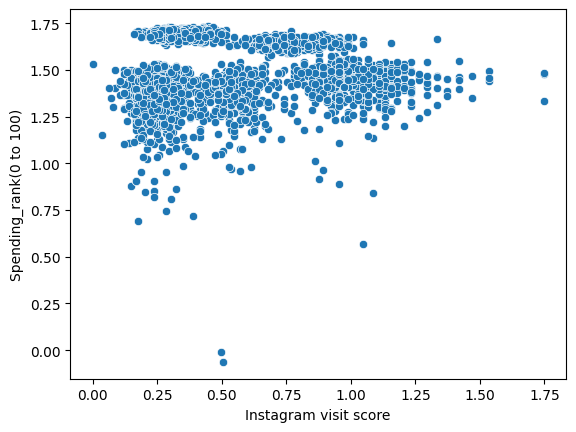

In [ ]:
sns.scatterplot(x="Instagram visit score",y="Spending_rank(0 to 100)",data=df)

# Modelling
* k-means Clustering

In [ ]:
* FIRST OF ALL WE HAVE TO GRAM ELBOW CURVE USING LINE PLOT

📌 WCSS Formula (Within-Cluster Sum of Squares)

𝑊
𝐶
𝑆
𝑆
=
∑
𝑖
=
1
𝐾
∑
𝑥
∈
𝐶
𝑖
∥
𝑥
−
𝜇
𝑖
∥
2
WCSS=∑
i=1
K
	​

∑
x∈C
i
	​

	​

∥x−μ
i
	​

∥
2

🧠 Explanation in simple terms
𝐾
K → number of clusters
𝐶
𝑖
C
i
	​

 → cluster
𝑖
i
𝑥
x → data point in that cluster
𝜇
𝑖
μ
i
	​

 → centroid (center) of cluster
𝑖
i
∥
𝑥
−
𝜇
𝑖
∥
2
∥x−μ
i
	​

∥
2
 → squared distance between point and centroid

In [ ]:
x=df

In [ ]:
wcss=[]
for k in range(1,11):
  from sklearn.cluster import KMeans
  kmeans1=KMeans(n_clusters=k,init="k-means++", random_state=42)
  kmeans1.fit(x)
  wcss.append(kmeans1.inertia_)
print(wcss)

[328.2610349027812, 129.66150240111205, 85.75577657363901, 69.29076198144855, 45.201656460663415, 37.29425078087289, 33.649984154167925, 29.637235514772744, 26.038475807396065, 23.913943909649326]


* using elbow method we have plot line chat


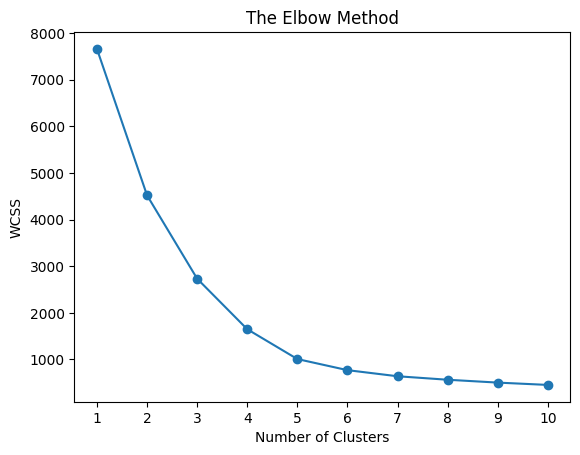

In [71]:
from matplotlib import markers
plt.plot(range(1,11),wcss,marker="o")
plt.xticks(range(1,11))
plt.title("The Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [72]:
from sklearn.metrics import silhouette_score

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(x)
    score = silhouette_score(x, labels)
    print(k, score)

2 0.5792620838029053
3 0.6778235367137232
4 0.7206921726543747
5 0.8779004217810671
6 0.7997372971178835


* using elbow method we found that k value is 5:
* Again we have to tarin the model

In [ ]:
from sklearn.cluster import KMeans
kmeans2=KMeans(n_clusters=5,init="k-means++",random_state=True)
# random_state will pick random centriods each everynew run
# init is used to intialize the centriods beferee the model evaluation

In [ ]:
x["km_cluster"]=kmeans2.fit_predict(x)
# fit means train the model
# predict mens it will give to the clusterss

<Axes: xlabel='Instagram visit score', ylabel='Spending_rank(0 to 100)'>

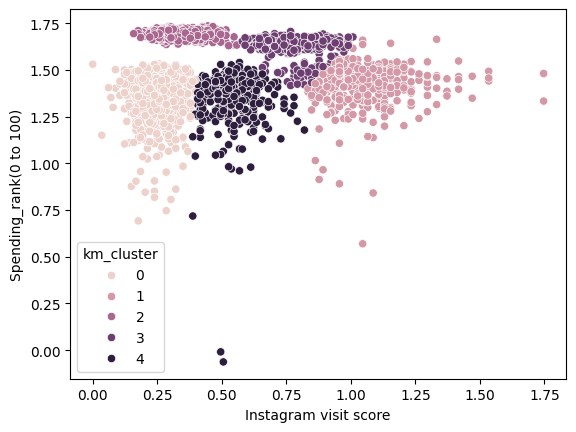

In [ ]:
sns.scatterplot(x="Instagram visit score",y="Spending_rank(0 to 100)",hue="km_cluster",data=x)
#Instagram activity vs Spending
# Colored by cluster
#Function to create a scatter plot
# Each point = one data row (user)
#👉 X-axis (horizontal)
#Shows Instagram activity
#More right → higher activity
#y="Spending_rank(0 to 100)"
#👉 Y-axis (vertical)
#Shows spending behavior
#Higher → more spending
#4️⃣ hue="km_cluster"
#👉 This is the most important part
#Colors points based on cluster
#Each cluster gets a different color

#Observations from the Scatter Plot

* This chart shows Instagram visit score vs. Spending rank with 5 K-means   clusters (0–4).
* Key Observations:
1. Cluster Distribution

* Cluster 0 (light pink) — Spread across low Instagram scores (0–0.5) with moderate spending ranks (0.75–1.75)
* Cluster 1 (medium pink) — Widely scattered, covering mid-to-high Instagram scores with moderate-high spending
* Cluster 2 (medium purple) — Concentrated around Instagram scores 0.4–0.8, high spending rank (~1.5–1.75)
* Cluster 3 (dark purple) — Mixed range, moderate Instagram scores
* Cluster 4 (near black) — Concentrated around Instagram score ~0.5, with a few extreme outliers near spending rank 0

2. Spending Rank Patterns

Most users cluster between spending rank 1.25–1.75, regardless of Instagram activity
Very few users have spending ranks below 0.5 — these appear as outliers

3. Instagram Visit Score

Majority of users score between 0.0–1.25 on Instagram visits
High Instagram scores (>1.25) show sparser data points

4. Outliers

A few points near (0.5, 0.0) stand out as anomalies — very low spending despite moderate Instagram usage

5. No Strong Linear Trend

There's no clear positive/negative correlation between Instagram visits and spending rank overall

* Instagram Visit Score=​V−Vmin​​/Vmax-Vmin

* Spending Score=​S−Smin​​/Smax-Smin

In [84]:
df = df.drop(columns='km_cluster')

In [85]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_scaled=sc.fit_transform(df)
x_scaled=pd.DataFrame(x_scaled,columns=df.columns)
x_scaled

,Instagram visit score,Spending_rank(0 to 100)
0,-0.110180,-0.340045
1,-0.044302,-0.275684
2,-1.335925,-0.706301
3,-0.700180,1.182922
4,2.219131,0.015172
...,...,...
2549,1.439765,-0.248180
2550,0.265175,-1.810420
2551,-1.222415,1.159994
2552,-0.847716,-0.559381


[1 1 5 ... 2 8 3]


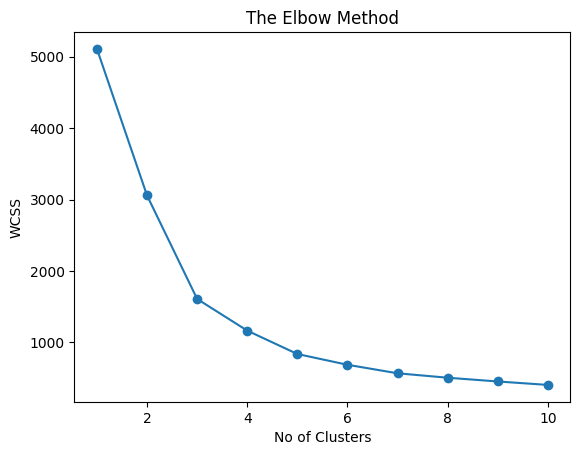

In [87]:
from sklearn.cluster import KMeans
wcss = []

for i in range(1, 11):
    km = KMeans(n_clusters = i, init = 'k-means++', random_state = 42, n_init = 10)
    km.fit(x_scaled)
    wcss.append(km.inertia_)

plt.plot(range(1, 11), wcss, marker = 'o')
plt.title('The Elbow Method')
plt.xlabel('No of Clusters')
plt.ylabel('WCSS')
print(km.labels_)

[3 3 3 ... 1 3 2]
[[ 1.57516386 -0.37560778]
 [-0.62051053  1.15199137]
 [ 0.76899365  0.813199  ]
 [-0.69044981 -0.5604987 ]
 [-0.52067634 -2.15724439]]


Text(0.5, 1.0, 'Clusters')

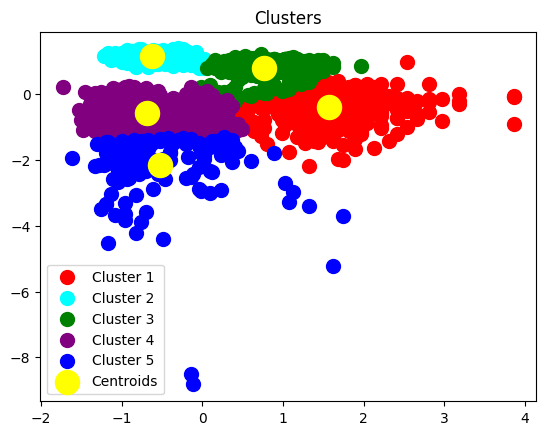

In [88]:
x_scaled_np=x_scaled.values
km=KMeans(n_clusters=5,init="k-means++",random_state=True,n_init=10)
y_km=km.fit_predict(x_scaled_np)
print(km.labels_)
print(km.cluster_centers_)
plt.scatter(x_scaled_np[y_km == 0,0], x_scaled_np[y_km == 0,1], s = 100, c = 'red', label = 'Cluster 1')
plt.scatter(x_scaled_np[y_km == 1,0], x_scaled_np[y_km == 1,1], s = 100, c = 'cyan', label = 'Cluster 2')
plt.scatter(x_scaled_np[y_km == 2,0], x_scaled_np[y_km == 2,1], s = 100, c = 'green', label = 'Cluster 3')
plt.scatter(x_scaled_np[y_km == 3,0], x_scaled_np[y_km == 3,1], s = 100, c = 'purple', label = 'Cluster 4')
plt.scatter(x_scaled_np[y_km==4,0],x_scaled_np[y_km==4,1],s=100,c="blue",label="Cluster 5")

plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], s = 300, c = 'yellow', label = 'Centroids')
plt.legend()
plt.title('Clusters')

In [74]:
from sklearn.metrics import silhouette_score

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(x)
    score = silhouette_score(x, labels)
    print(k, score)

2 0.5792620838029053
3 0.6778235367137232
4 0.7206921726543747
5 0.8779004217810671
6 0.7997372971178835


In [75]:
cluster_means = x.groupby('km_cluster')[['Instagram visit score', 'Spending_rank(0 to 100)']].mean()
display(cluster_means)

,Instagram visit score,Spending_rank(0 to 100)
km_cluster,,
0,0.255376,1.359344
1,1.054255,1.417951
2,0.346914,1.692471
3,0.785680,1.624631
4,0.540574,1.343464


In [76]:
cluster_means = x.groupby('km_cluster')[['Instagram visit score', 'Spending_rank(0 to 100)']].mean()
display(cluster_means)

,Instagram visit score,Spending_rank(0 to 100)
km_cluster,,
0,0.255376,1.359344
1,1.054255,1.417951
2,0.346914,1.692471
3,0.785680,1.624631
4,0.540574,1.343464
